# CIENCIA DE LA COMPUTACION
### Facultad de Ciencias 
---
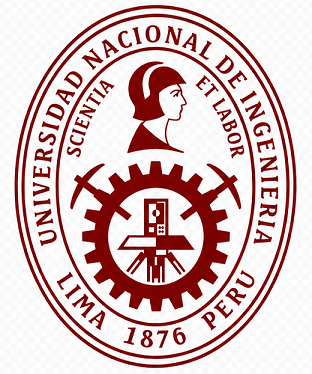
---

### Curso: Inteligencia Artificial (CC421A)
### Profesor: Dr. Marco Antonio Alania Vicente

---
---
## TEMA: REDES NEURONALES CONVOLUCIONALES (CNN)
---
---

# [1] CNN_1 - Deteccion de Numeros
Se hara la importacion de la base de datos MNIST(de la libreria tensorflow_datasets), el cual tiene escrito numero escrito a mano. Las imagenes son de tamaños 28x28 pixeles en un solo canal (escala de grises). Cada pixel tiene un valor que va de 0-255. La data se separa en data de entrenamiento 60k y data de prueba 10k

### [1.1] IMPORTACION DE DATOS PARA LAS RED NEURONAL

Se descarga la data y se guarda en cache de la maquina

In [1]:
#importacion de paquetes
import tensorflow as tf
import tensorflow_datasets as tfds

#descargar set de datos de MNIST (Numeros escritos a mano, etiquetados)
datos, metadatos = tfds.load('mnist', as_supervised=True, with_info=True)

#obtener en variables separadas los datos de entrenamiento (60k) y pruebas (10k)
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

#funcion de normalizacion para los datos (Pasar valor de los pixeles de 0-255 a 0-1, esto hace que la red aprenda mejor y mas rapido)
def normalizar(imagenes, etiquetas):
  imagenes = tf.cast(imagenes, tf.float32)
  imagenes /= 255 #Aqui se pasa de 0-255 a 0-1
  return imagenes, etiquetas

#normalizar los datos de entrenamiento y prueba con la funcion que hicimos anteriormente
datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

#agregar a cache (usar memoria en lugar de disco, entrenamiento mas rapido)
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

clases = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\Usuario\tensorflow_datasets\mnist\incomplete.H2A0LB_3.0.1\mnist-train.tfrecord-[0-9][0-9][0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\Usuario\tensorflow_datasets\mnist\incomplete.H2A0LB_3.0.1\mnist-test.tfrecord-[0-9][0-9][0-…

Dataset mnist downloaded and prepared to C:\Users\Usuario\tensorflow_datasets\mnist\3.0.1. Subsequent calls will reuse this data.


MUESTRA IMAGENES DEL SET DE DATOS, SOLO LOS 20 PRIMEROS DATOS DE ENTRENAMIENTO


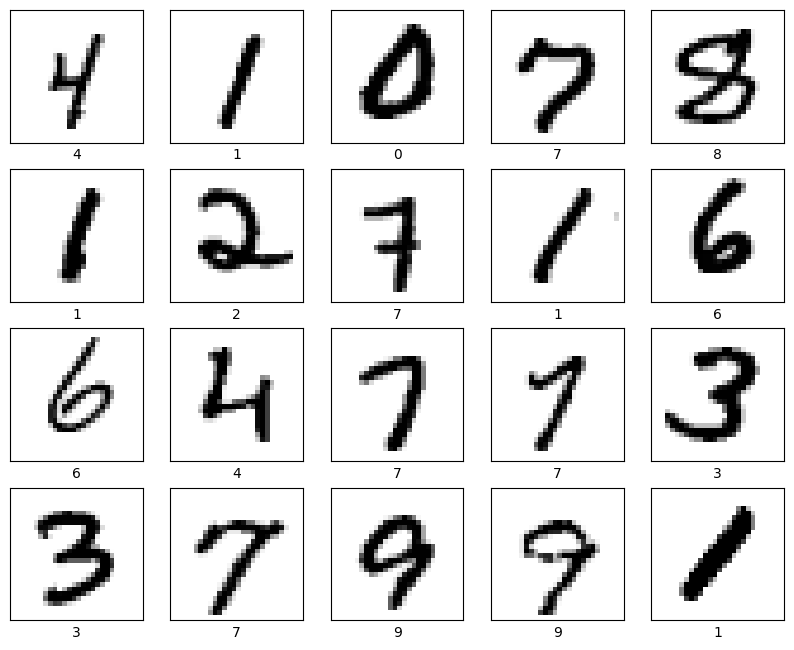

In [2]:
#importacion de libreria
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))

for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(20)):
  imagen = imagen.numpy().reshape((28,28))
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(imagen, cmap=plt.cm.binary)
  plt.xlabel(clases[etiqueta])

plt.show()

### [1.2] PRUEBA 1: RED NEURONAL CLASICA (FC)
En esta prueba cada imagen de entrada (28x28 pixeles), solo lo convetimos a una red neuronal, sin hacer la capa de convolucion.

In [3]:
#CREACION DE MODELO FC SIN CONVOLUCION (Modelo denso, regular, sin redes convolucionales todavia)

modelo = tf.keras.Sequential([
    #especifica que las imágenes de entrada son de tamaño 28×28 y tienen 1 canal (blanco y negro).
    tf.keras.layers.Input(shape=(28, 28, 1)),  #1 = blanco y negro

    #aplana la imagen de 28×28 a un vector de 784 elementos para conectarla a la capa densa.
    tf.keras.layers.Flatten(),

    #primera capa oculta completamente conectadas con función de activación ReLU.
    tf.keras.layers.Dense(units=50, activation='relu'),

    #segunda capa oculta completamente conectadas con función de activación ReLU.
    tf.keras.layers.Dense(units=50, activation='relu'),

    #capa de salida con 10 neuronas (una por clase) usando softmax para clasificación multiclase.
    tf.keras.layers.Dense(10, activation='softmax')
])

#Compilar el modelo anteriormente definido
modelo.compile(
    #optimizador eficiente que combina las ventajas de AdaGrad y RMSProp.
    optimizer='adam',

    #se usa cuando las etiquetas son enteros (0 a 9), no es one-hot encoding
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    #se reporta la exactitud durante entrenamiento y validación
    metrics=['accuracy']
)

La data se secciona para data de entrenamiento(60k) y la data de prueba(10k)

In [4]:
#Los numeros de datos de entrenamiento y pruebas (60k y 10k)
num_datos_entrenamiento = metadatos.splits["train"].num_examples
num_datos_pruebas = metadatos.splits["test"].num_examples

#Trabajar por lotes
TAMANO_LOTE=32

#Shuffle y repeat hacen que los datos esten mezclados de manera aleatoria
#para que el entrenamiento no se aprenda las cosas en orden
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_datos_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

Se realiza el entramiento con a data seccionada (tiemp aprox 3 min)

In [5]:
#Realizar el entrenamiento
import math

historial = modelo.fit(
    datos_entrenamiento,
    epochs=60,
    steps_per_epoch=math.ceil(num_datos_entrenamiento/TAMANO_LOTE)
)

Epoch 1/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9154 - loss: 0.2914
Epoch 2/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9578 - loss: 0.1400
Epoch 3/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9687 - loss: 0.1037
Epoch 4/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9742 - loss: 0.0838
Epoch 5/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9785 - loss: 0.0699
Epoch 6/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9815 - loss: 0.0586
Epoch 7/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9832 - loss: 0.0529
Epoch 8/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9856 - loss: 0.0436
Epoch 9/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9872 - loss: 0.0409
Epoch 10/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9890 - loss: 0.0351
Epoch 11/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9894 - loss: 0.0318
Epoch 12/60
1875/1875 ━━━━━━━━

Se imprime los primero numero con las etiqueta R(Imagen Real) y la etiqueta P(Imagen predicho)

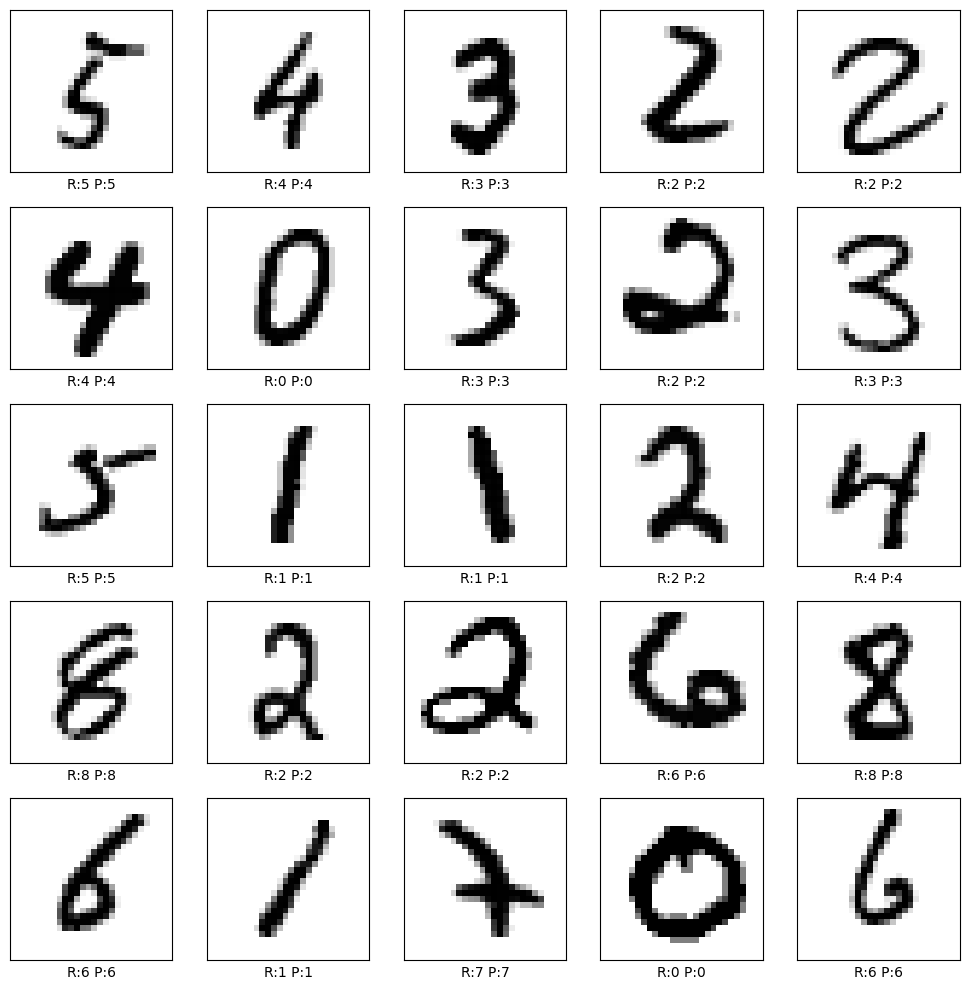

In [6]:
#importacion de libreria
import matplotlib.pyplot as plt

# Convertimos el dataset a lista para acceso por índice
datos_pruebas_lista = list(datos_pruebas.unbatch().as_numpy_iterator())

# Define el rango que quieres visualizar(datos de pruba 10k)
inicio = 125
fin = 150  # Por ejemplo, 25 imágenes

plt.figure(figsize=(10,10))

for i, idx in enumerate(range(inicio, fin)):
    imagen, etiqueta_real = datos_pruebas_lista[idx]

    # Preparar imagen para predicción
    imagen_input = tf.expand_dims(imagen, axis=0)
    prediccion = modelo.predict(imagen_input, verbose=0)
    etiqueta_predicha = tf.argmax(prediccion[0]).numpy()

    # Mostrar imagen en la grilla
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen.reshape(28, 28), cmap=plt.cm.binary)
    plt.xlabel(f"R:{etiqueta_real} P:{etiqueta_predicha}")

plt.tight_layout()
plt.show()

Barremos toda la data en testeo(10k) y vemos la cantidad de errores predicho del modelo

Evaluando imágenes: 100%|██████████| 10000/10000 [12:48<00:00, 13.01it/s]



####### RESUMEN DE LA RED NEURONAL FC  #######
Total de datos de prueba revisados: 10000
Total de errores encontrados: 273
Porcentaje de error del modelo: 2.73%


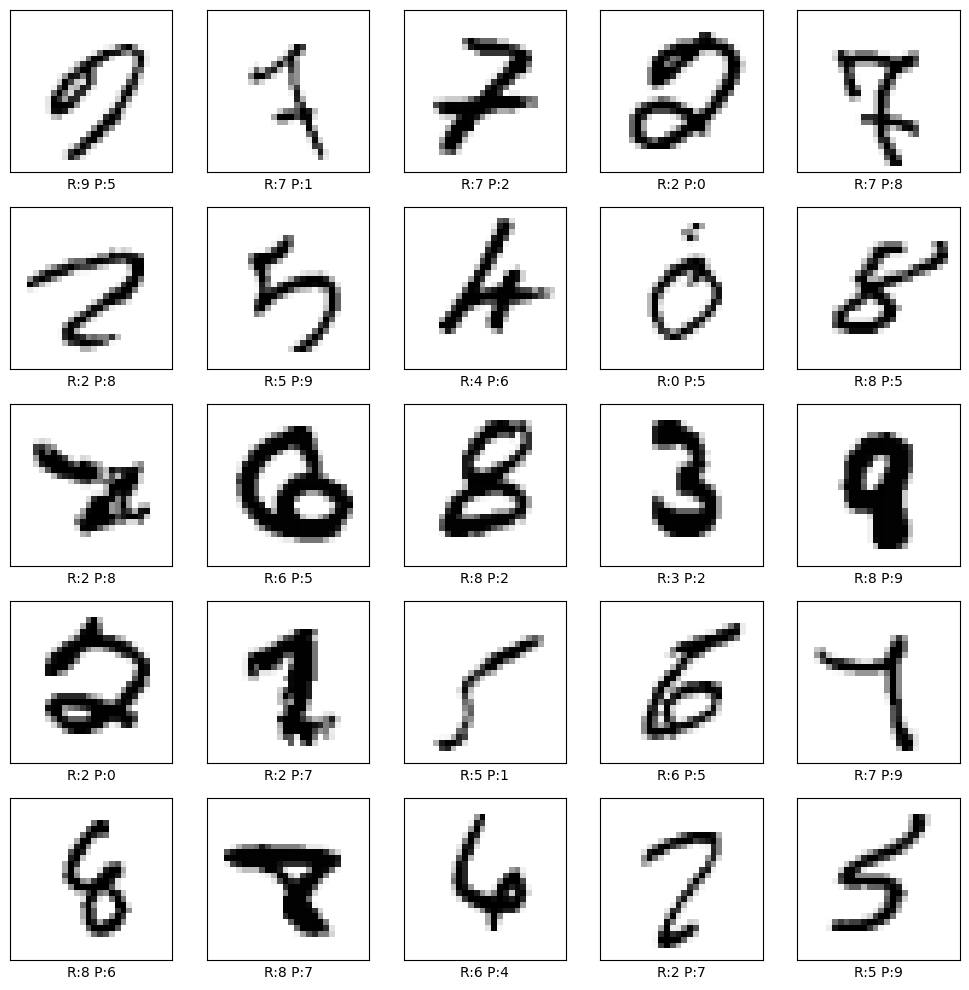

In [7]:
# EN ESTA PARTE REVISAMOS LOS ERRORES DE PREDICION QUE TUVO EL MODELO

import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm  # <- importar tqdm

# Convertimos el dataset a lista para acceso secuencial
datos_pruebas_lista = list(datos_pruebas.unbatch().as_numpy_iterator())

errores = []  # Lista para guardar tuplas (índice, imagen, etiqueta_real, etiqueta_predicha)

# Envolvemos tqdm alrededor del iterador
for i, (imagen, etiqueta_real) in tqdm(enumerate(datos_pruebas_lista), total=len(datos_pruebas_lista), desc="Evaluando imágenes"):
    imagen_input = tf.expand_dims(imagen, axis=0)
    prediccion = modelo.predict(imagen_input, verbose=0)
    etiqueta_predicha = tf.argmax(prediccion[0]).numpy()

    if etiqueta_predicha != etiqueta_real:
        errores.append((i, imagen, etiqueta_real, etiqueta_predicha))

print("\n####### RESUMEN DE LA RED NEURONAL FC  #######")
print(f"Total de datos de prueba revisados: {len(datos_pruebas_lista)}")
print(f"Total de errores encontrados: {len(errores)}")
print(f"Porcentaje de error del modelo: {100*(len(errores)/len(datos_pruebas_lista)):.2f}%")

# Mostrar los primeros 25 errores en una grilla
plt.figure(figsize=(10,10))

for i, (idx, imagen, real, pred) in enumerate(errores[:25]):
    plt.subplot(5, 5, i + 1)
    plt.imshow(imagen.reshape(28, 28), cmap=plt.cm.binary)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.xlabel(f"R:{real} P:{pred}")

plt.tight_layout()
plt.show()

## [1.3] PRUEBA 2: RED NEURONAL CONVOLUCIONAL (CNN)
Esta prueba cada imagen de entrada, pasa primero por una primera convolucion luego pasa por un maxpooling, luego pasa a la segunda capa de convolucion para luego pasar por un maxpooling. Finalmente pasa a la red neuronal FC.

In [13]:
# IMPORTACION DE DATOS PARA LAS REDES NEURONALES CNN

#importacion de paquetes
import tensorflow as tf
import tensorflow_datasets as tfds

#descargar set de datos de MNIST (Numeros escritos a mano, etiquetados)
datos, metadatos = tfds.load('mnist', as_supervised=True, with_info=True)

#obtener en variables separadas los datos de entrenamiento (60k) y pruebas (10k)
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

#funcion de normalizacion para los datos (Pasar valor de los pixeles de 0-255 a 0-1)
#(Hace que la red aprenda mejor y mas rapido)
def normalizar(imagenes, etiquetas):
  imagenes = tf.cast(imagenes, tf.float32)
  imagenes /= 255 #Aqui se pasa de 0-255 a 0-1
  return imagenes, etiquetas

#normalizar los datos de entrenamiento y prueba con la funcion que hicimos anteriormente
datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

#agregar a cache (usar memoria en lugar de disco, entrenamiento mas rapido)
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

clases = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

#Los numeros de datos de entrenamiento y pruebas (60k y 10k)
num_datos_entrenamiento = metadatos.splits["train"].num_examples
num_datos_pruebas = metadatos.splits["test"].num_examples

#Trabajar por lotes
TAMANO_LOTE=32

#Shuffle y repeat hacen que los datos esten mezclados de manera aleatoria
#para que el entrenamiento no se aprenda las cosas en orden
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_datos_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

Creacion de Modelo con capas convolucional (CNN)

In [16]:
# importacion del tensorflow
import tensorflow as tf

# Crear el modelo convolucional (CNN)
modelo = tf.keras.Sequential([
    # Entrada: imágenes 28x28 con 1 canal (escala de grises)
    tf.keras.layers.Input(shape=(28, 28, 1)),

    # Primera capa convolucional: 32 filtros, kernel 3x3, activación ReLU
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),

    # Capa de reducción espacial (max pooling) 2x2
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Segunda capa convolucional: 64 filtros
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),

    # Otro max pooling 2x2
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Aplanamiento para conectar con la capa densa
    tf.keras.layers.Flatten(),

    # Capa densa (completamente conectada)
    tf.keras.layers.Dense(units=64, activation='relu'),

    # Capa de salida para clasificación (10 clases)
    tf.keras.layers.Dense(units=10, activation='softmax')
])

# Compilar el modelo
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)


Entrenamiento del modelo con la data de entranamiento (8 min aprox)

In [17]:
#importacion de la libreria math
import math

# entrenamiento
historial = modelo.fit(
    datos_entrenamiento,
    epochs=60,
    steps_per_epoch=math.ceil(num_datos_entrenamiento/TAMANO_LOTE)
)

Epoch 1/60


1875/1875 [==============================] - 17s 8ms/step - loss: 0.1372 - accuracy: 0.9589
Epoch 2/60
1875/1875 [==============================] - 14s 7ms/step - loss: 0.0440 - accuracy: 0.9868
Epoch 3/60
1875/1875 [==============================] - 14s 7ms/step - loss: 0.0300 - accuracy: 0.9907
Epoch 4/60
1875/1875 [==============================] - 14s 7ms/step - loss: 0.0222 - accuracy: 0.9930
Epoch 5/60
1875/1875 [==============================] - 14s 7ms/step - loss: 0.0178 - accuracy: 0.9942
Epoch 6/60
1875/1875 [==============================] - 15s 8ms/step - loss: 0.0131 - accuracy: 0.9957
Epoch 7/60
1875/1875 [==============================] - 14s 7ms/step - loss: 0.0111 - accuracy: 0.9962
Epoch 8/60
1875/1875 [==============================] - 14s 8ms/step - loss: 0.0092 - accuracy: 0.9968
Epoch 9/60
1875/1875 [==============================] - 16s 9ms/step - loss: 0.0076 - accuracy: 0.9974
Epoch 10/60
1875/1875 [==============================] - 15s 8ms/step - loss: 0.0068

Se imprime los primero numero con las etiqueta R(Imagen Real) y la etiqueta P(Imagen predicho)

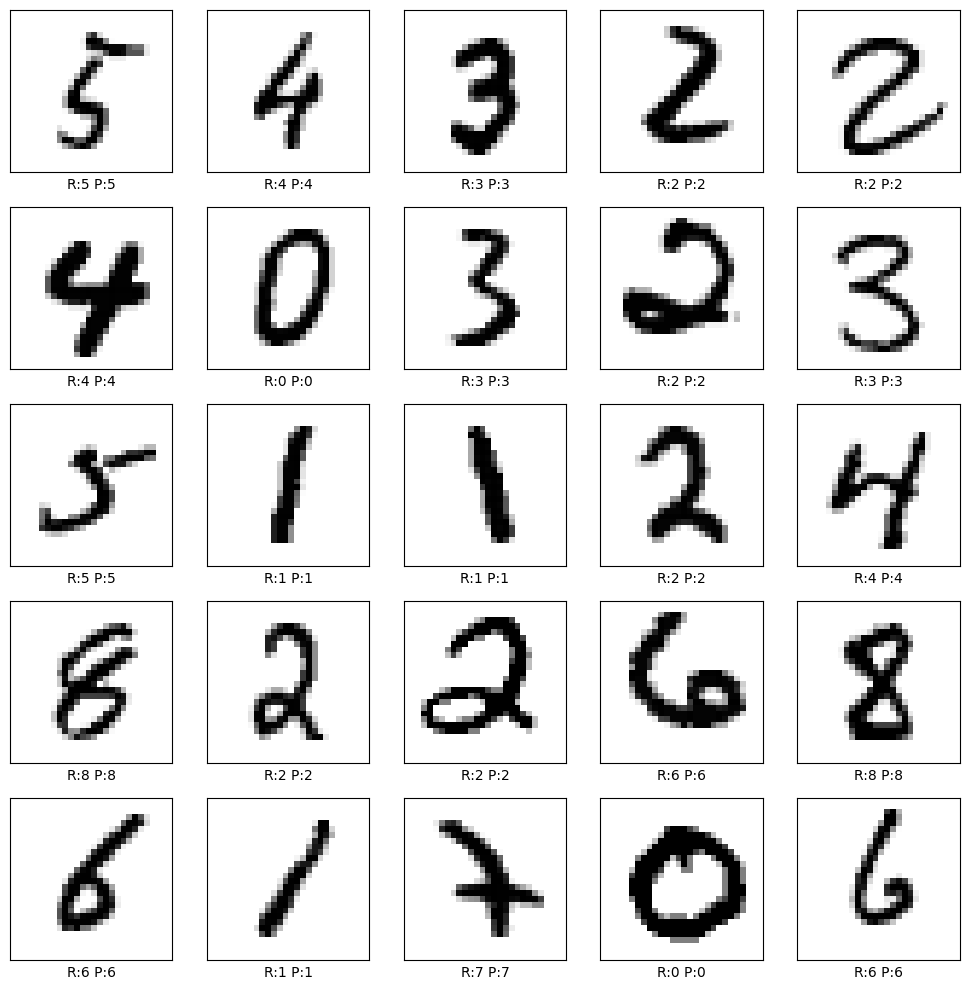

In [18]:
import matplotlib.pyplot as plt

# Convertimos el dataset a lista para acceso por índice
datos_pruebas_lista = list(datos_pruebas.unbatch().as_numpy_iterator())

# Define el rango que quieres visualizar(datos de pruba 10k)
inicio = 125
fin = 150  # Por ejemplo, 25 imágenes

plt.figure(figsize=(10,10))

for i, idx in enumerate(range(inicio, fin)):
    imagen, etiqueta_real = datos_pruebas_lista[idx]

    # Preparar imagen para predicción
    imagen_input = tf.expand_dims(imagen, axis=0)
    prediccion = modelo.predict(imagen_input, verbose=0)
    etiqueta_predicha = tf.argmax(prediccion[0]).numpy()

    # Mostrar imagen en la grilla
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen.reshape(28, 28), cmap=plt.cm.binary)
    plt.xlabel(f"R:{etiqueta_real} P:{etiqueta_predicha}")

plt.tight_layout()
plt.show()

Barremos toda la data en testeo(10k) y vemos la cantidad de errores predicho del modelo

Evaluando imágenes: 100%|██████████| 10000/10000 [11:54<00:00, 14.00it/s]



####### RESUMEN DE LA RED NEURONAL CONVOLUCIONAL (CNN)  #######
Total de datos de prueba revisados: 10000
Total de errores encontrados: 83
Porcentaje de error del modelo: 0.83%


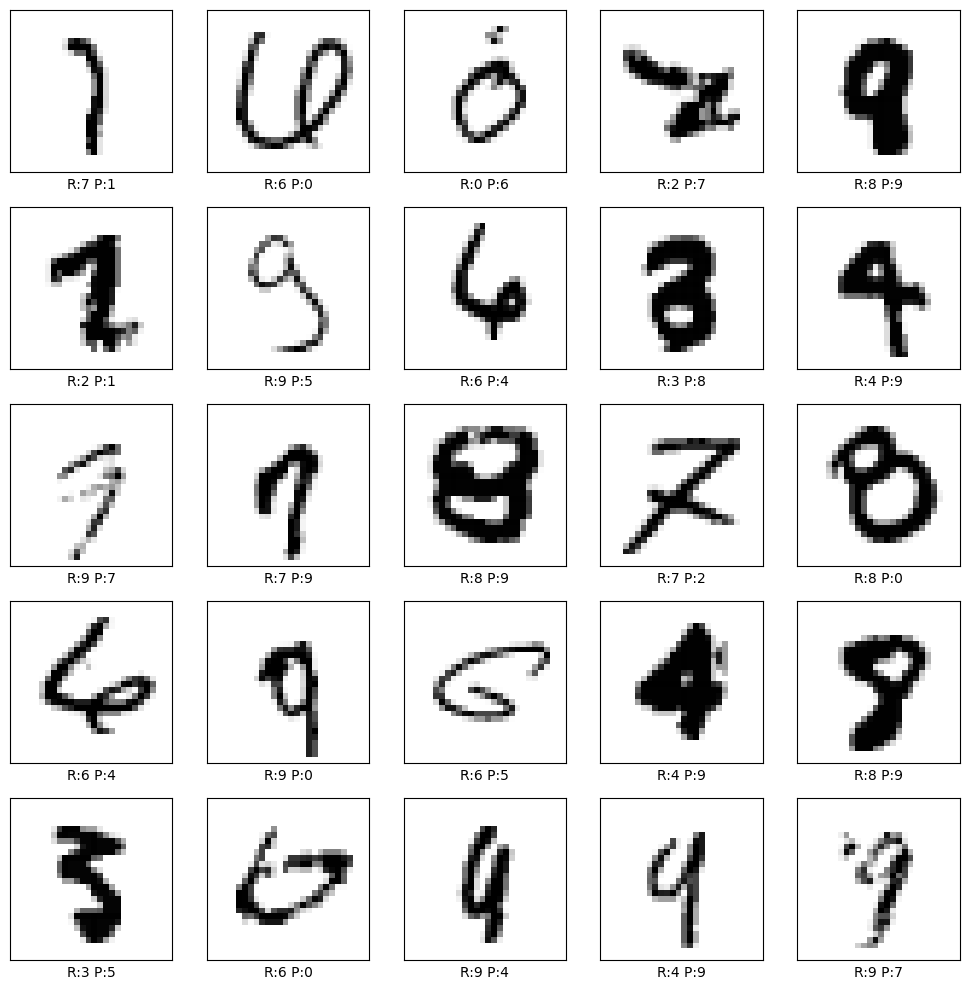

In [19]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm  # <- importar tqdm

# Convertimos el dataset a lista para acceso secuencial
datos_pruebas_lista = list(datos_pruebas.unbatch().as_numpy_iterator())

errores = []  # Lista para guardar tuplas (índice, imagen, etiqueta_real, etiqueta_predicha)

# Envolvemos tqdm alrededor del iterador
for i, (imagen, etiqueta_real) in tqdm(enumerate(datos_pruebas_lista), total=len(datos_pruebas_lista), desc="Evaluando imágenes"):
    imagen_input = tf.expand_dims(imagen, axis=0)
    prediccion = modelo.predict(imagen_input, verbose=0)
    etiqueta_predicha = tf.argmax(prediccion[0]).numpy()

    if etiqueta_predicha != etiqueta_real:
        errores.append((i, imagen, etiqueta_real, etiqueta_predicha))

print("\n####### RESUMEN DE LA RED NEURONAL CONVOLUCIONAL (CNN)  #######")
print(f"Total de datos de prueba revisados: {len(datos_pruebas_lista)}")
print(f"Total de errores encontrados: {len(errores)}")
print(f"Porcentaje de error del modelo: {100*(len(errores)/len(datos_pruebas_lista)):.2f}%")

# Mostrar los primeros 25 errores en una grilla
plt.figure(figsize=(10,10))

for i, (idx, imagen, real, pred) in enumerate(errores[:25]):
    plt.subplot(5, 5, i + 1)
    plt.imshow(imagen.reshape(28, 28), cmap=plt.cm.binary)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.xlabel(f"R:{real} P:{pred}")

plt.tight_layout()
plt.show()